# Predicting High-Quality White Wine Using Machine Learning

## Business Objective

The objective is to develop a classification model that predicts whether a white wine will be classified as high quality based on its physicochemical properties.

A high-quality wine is defined as one receiving a quality score of 6 or higher. Such a model could provide an initial data-driven quality assessment to support quality-control and product-screening processes in the wine and beverage industry.

## Research Questions

### Primary Research Question

Can a machine-learning classification model predict whether a white wine will receive a high-quality score based on its physicochemical properties?

### Secondary Research Questions

1. Which physicochemical properties have the strongest relationships with high-quality wine classification?

2. Which model—Logistic Regression or a tuned K-Nearest Neighbours Classifier—performs better at identifying high-quality white wines?

3. How well does the best model perform in terms of accuracy, precision, recall, F1-score, and ROC-AUC?

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

wine_df = pd.read_csv("https://raw.githubusercontent.com/fisicangel/Min-project-2-wine/main/winequality-white.csv", sep=";")

wine_df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## 1. Exploratory Data Analysis

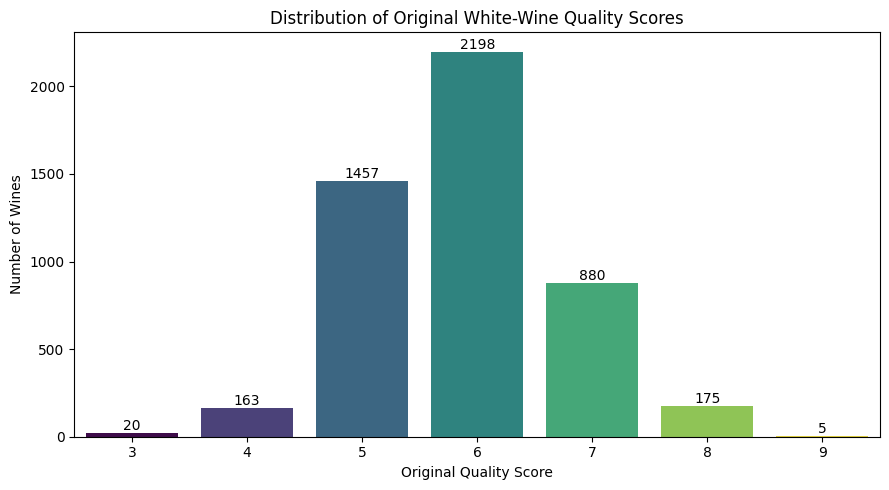

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 5))

ax = sns.countplot(
    data=wine_df,
    x="quality",
    hue="quality",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Original White-Wine Quality Scores")
plt.xlabel("Original Quality Score")
plt.ylabel("Number of Wines")

# Display the count above every bar
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

In [4]:
print("Number of rows:", wine_df.shape[0])
print("Number of columns:", wine_df.shape[1])

wine_df.info()

Number of rows: 4898
Number of columns: 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


## 2. Data Quality Checks

The dataset contains 4,898 white-wine observations and 12 columns.

All columns contain 4,898 non-null values, confirming that there are no missing values in the dataset. Therefore, no missing-value treatment, such as removing rows or filling values, is required.

The dataset will also be checked for duplicated rows before proceeding with the analysis and machine-learning model.

In [5]:
print("Number of duplicated rows:", wine_df.duplicated().sum())

Number of duplicated rows: 937


### Duplicate Treatment

The dataset contained 937 duplicated rows. These rows were removed to prevent identical observations from receiving excessive influence during model training and potentially appearing in both the training and test sets.

After removing duplicates, the cleaned dataset contains 3,961 unique observations.

In [6]:
wine_df = wine_df.drop_duplicates().reset_index(drop=True)

print("Number of rows after removing duplicates:", wine_df.shape[0])
print("Remaining duplicated rows:", wine_df.duplicated().sum())


Number of rows after removing duplicates: 3961
Remaining duplicated rows: 0


## 3. Target Distribution Analysis

The original target variable, `quality`, is an integer score representing the sensory quality assigned to each wine.

Because this project uses **classification**, the numerical quality scores will later be converted into categorical classes. However, the classification threshold should not be selected arbitrarily. We must first examine:

1. The number of observations in each quality category.
2. The percentage represented by each category.
3. Whether the proposed classes would be balanced.
4. Whether a majority-class prediction could already produce high accuracy.

For a quality score \(q\), a possible binary target can be expressed as: y = 0, if q < t
y = 1, if q ≥ t


where:

- \(q\) is the original wine-quality score,
- \(t\) is the classification threshold,
- \(y=0\) represents lower-quality wine,
- \(y=1\) represents higher-quality wine.

The threshold \(t\) will be selected after examining the target distribution.

In [7]:
# Count the number of wines for each quality score
quality_counts = wine_df["quality"].value_counts().sort_index()

# Calculate the percentage distribution
quality_percentages = (
    wine_df["quality"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

# Combine counts and percentages into one table
quality_distribution = pd.DataFrame({
    "count": quality_counts,
    "percentage": quality_percentages
})

quality_distribution

,count,percentage
quality,,
3,20,0.50
4,153,3.86
5,1175,29.66
6,1788,45.14
7,689,17.39
8,131,3.31
9,5,0.13


## 4. Target Engineering for Binary Classification

The original target, 'quality', contains integer scores from 3 to 9. For this classification task, it is converted into a binary target called  'quality-class'.

The classification rule is: yi​={0,1,​if qi​≤5if qi​≥6​)



where:

- \(q_i\) is the original quality score for wine \(i\),
- \(y_i\) is the newly engineered binary target,
- `0` represents lower-quality wine,
- `1` represents acceptable or higher-quality wine.

The original 'quality' column is retained for interpretation, while 'quality_class' becomes the target used for classification.

This is **target engineering**, not one-hot encoding. One-hot encoding is unnecessary for the predictor variables because all original wine features are numerical.

In [8]:
import numpy as np

# Create the binary classification target
wine_df["quality_class"] = np.where(
    wine_df["quality"] >= 6,
    1,
    0
)

wine_df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,6,1
1,6,1
2,6,1
3,6,1
4,6,1
5,6,1
6,5,0
7,5,0
8,5,0
9,7,1


In [9]:
target_check = (
    wine_df
    .groupby(["quality", "quality_class"])
    .size()
    .reset_index(name="count")
)

target_check

,quality,quality_class,count
0,3,0,20
1,4,0,153
2,5,0,1175
3,6,1,1788
4,7,1,689
5,8,1,131
6,9,1,5


### 5. Rare Target Values and Potential Outliers

The original quality distribution contains several rare scores. In particular, only 20 wines received a quality score of 3, while only 5 wines received a score of 9.

However, a **rare target value** is not automatically an outlier. Rarity describes how frequently a value occurs, whereas an outlier is an observation that lies unusually far from the general distribution.

Before target engineering, "quality" is an ordinal numerical target. After converting the project into a binary classification problem, the original quality scores are grouped as follows:

{3, 4, 5} → 0

{6, 7, 8, 9} → 1

The classes are interpreted as:

- "quality_class" = 0`: below acceptable quality
- "quality_class" = 1`: acceptable-to-higher quality

The number of observations in class 0 is:

20 + 153 + 1175 = 1348

The number of observations in class 1 is:

1788 + 689 + 131 + 5 = 2613

Therefore, the final binary target distribution is approximately:

P(y = 0) = (1348 / 3961) × 100 ≈ 34.03%

P(y = 1) = (2613 / 3961) × 100 ≈ 65.97%

The classification model is not required to predict quality score 9 as an individual class using only five observations. Instead, those wines become part of "quality_class" = 1`, which contains 2,613 observations.

Although the binary classes are not perfectly balanced, both classes contain enough observations for model training. A stratified train-test split will be used to preserve these class proportions in both the training and test datasets.

The rare original quality scores will not be removed simply because they occur infrequently. They may represent genuine wines, and removing valid observations could artificially increase model performance and reduce the model’s ability to generalize to unusual wines.

### Potential Outliers in the Predictor Variables

Potential outliers in the physicochemical predictor variables will be investigated separately using boxplots and the interquartile range.

The interquartile range is calculated as:

IQR = Q3 − Q1
Potential outliers are observations outside the following boundaries:

Lower bound = Q1 − 1.5 × IQR

Upper bound = Q3 + 1.5 × IQR

Outliers may affect some machine-learning methods more strongly than others. K-Nearest Neighbors calculates the distance between observations. Using Euclidean distance:
The formula for **Euclidean distance** between two points is:


$$d(p,q) = \sqrt{\sum_{i=1}^{n}(p_i - q_i)^2}$$

d(p, q) = distance between two wines
p and q = the two wines being compared
i = each feature/column
n = total number of features
pᵢ and qᵢ = values of feature i for wines p and q



An extreme value in one feature can dominate the distance calculation, causing KNN to identify misleading nearest neighbors.

Outliers can also affect feature scaling:

- "StandardScaler" uses the mean and standard deviation, which are sensitive to extreme values.
- "MinMaxScaler" uses the minimum and maximum, so an extreme value can compress most observations into a narrow range.

However, an observation identified by the IQR rule is only a **potential statistical outlier**. It should not be removed automatically. Each potential outlier must first be investigated to determine whether it is:

- a data-entry error,
- a measurement error,
- physically impossible,
- or a valid but unusual wine.

The approach used in this project is therefore:

> Detect potential outliers, investigate their validity and remove them only when there is sufficient analytical justification.

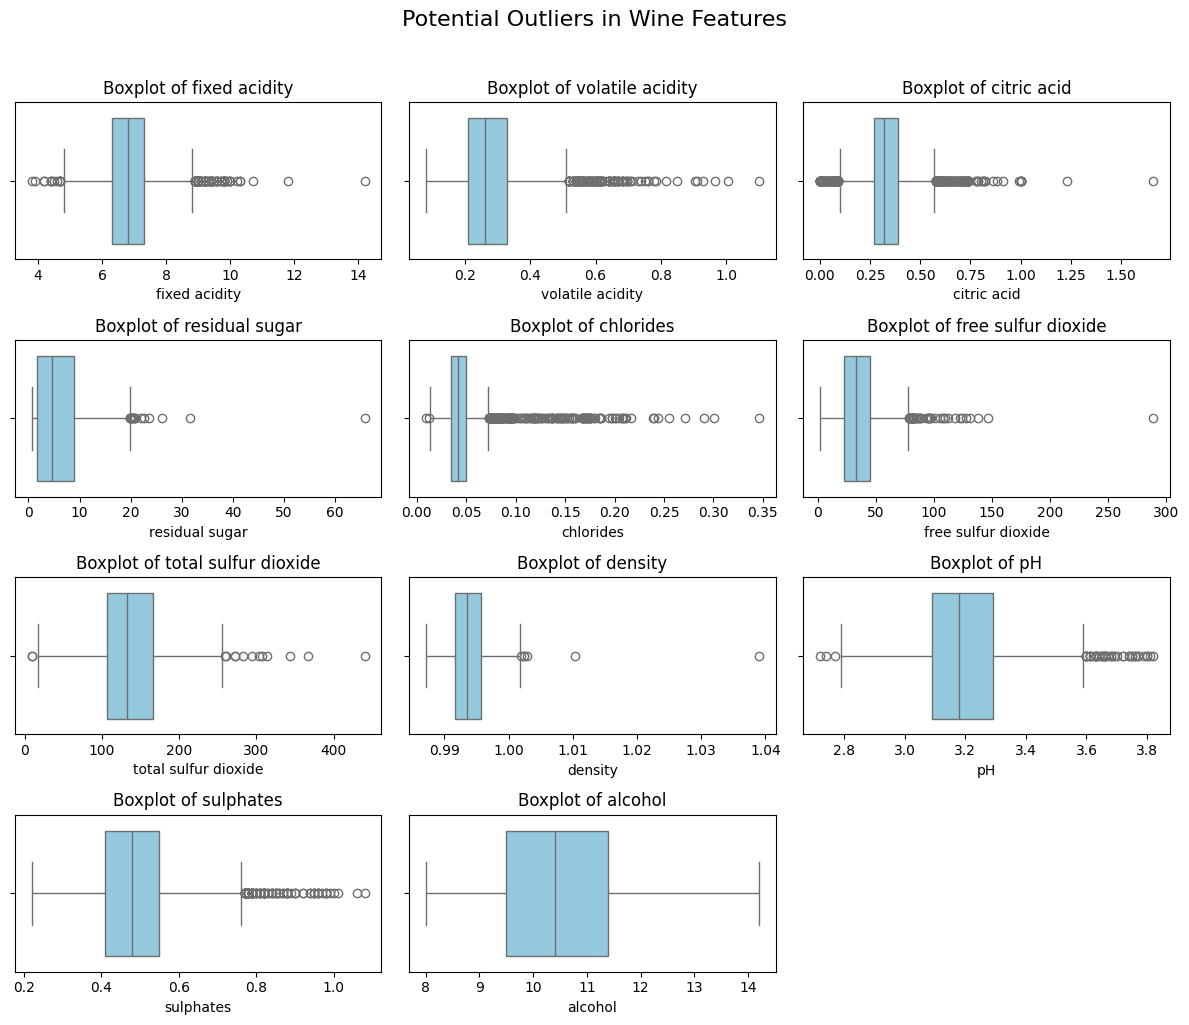

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the 11 predictor variables
feature_columns = wine_df.drop(
    columns=["quality", "quality_class"]
).columns

# Create a subplot containing 4 rows and 3 columns
fig, axes = plt.subplots(4, 3, figsize=(12, 10))

# Convert the two-dimensional axes into a one-dimensional list
axes = axes.flatten()

# Create one boxplot for each predictor variable
for index, column in enumerate(feature_columns):
    sns.boxplot(
        x=wine_df[column],
        ax=axes[index],
        color="skyblue"
    )

    axes[index].set_title(f"Boxplot of {column}")
    axes[index].set_xlabel(column)

# Delete the unused twelfth subplot
for index in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[index])

plt.suptitle(
    "Potential Outliers in Wine Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

### 5.1 Initial Interpretation of the Feature Boxplots

The boxplots indicate potential outliers in several physicochemical features. The most noticeable upper-tail observations appear in volatile acidity, citric acid, residual sugar, chlorides and free sulfur dioxide.

Some features, particularly residual sugar and chlorides, also appear positively skewed. A positively skewed distribution has a longer right tail because most observations are concentrated at lower values while a smaller number have much higher values.

However, the points outside the boxplot whiskers are not automatically data errors. Wine composition can naturally contain unusual but valid measurements. Removing all observations identified by the IQR rule could discard genuine wines, reduce the sample size and create selection bias.

Potential outliers may influence distance-based models such as KNN because the model calculates distances between observations. They may also affect `StandardScaler`, which uses the mean and standard deviation.

Therefore, no observations will be removed solely because they appear outside the boxplot whiskers. The potential outliers will first be quantified and checked for physical plausibility. Model performance can later be compared using standardization, normalization and, if justified, a robust preprocessing method.

In [12]:
outlier_summary = []

for column in feature_columns:
    Q1 = wine_df[column].quantile(0.25)
    Q3 = wine_df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (
        (wine_df[column] < lower_bound) |
        (wine_df[column] > upper_bound)
    )

    outlier_count = outlier_mask.sum()
    outlier_percentage = outlier_count / len(wine_df) * 100

    outlier_summary.append({
        "feature": column,
        "lower_bound": round(lower_bound, 4),
        "upper_bound": round(upper_bound, 4),
        "potential_outliers": outlier_count,
        "percentage": round(outlier_percentage, 2)
    })

outlier_summary_df = pd.DataFrame(outlier_summary)
outlier_summary_df.sort_values(
    "percentage",
    ascending=False
).reset_index(drop=True)

,feature,lower_bound,upper_bound,potential_outliers,percentage
0,citric acid,0.0900,0.5700,223,5.63
1,chlorides,0.0125,0.0725,178,4.49
2,volatile acidity,0.0300,0.5100,133,3.36
3,fixed acidity,4.8000,8.8000,106,2.68
4,sulphates,0.2000,0.7600,96,2.42
5,pH,2.7900,3.5900,46,1.16
6,free sulfur dioxide,-10.0000,78.0000,44,1.11
7,residual sugar,-9.3500,19.8500,16,0.40
8,total sulfur dioxide,16.0000,256.0000,14,0.35
9,density,0.9855,1.0018,6,0.15


### 5.2 Quantitative Assessment of Potential Outliers

The IQR analysis identified potential outliers in 10 of the 11 predictor variables. Citric acid had the highest proportion at 5.63%, followed by chlorides at 4.49% and volatile acidity at 3.36%. Alcohol had no observations outside its calculated IQR boundaries.

The IQR method identifies observations using:

IQR = Q3 − Q1


\[
\]


\[
\text{Upper bound}=Q_3+1.5(IQR)
\]

These boundaries are statistical rules rather than scientific limits. For example, the lower IQR boundary for citric acid is 0.09. Consequently, chemically possible values between 0 and 0.09 may be labelled as potential outliers even though they are not necessarily errors.

Similarly, the calculated lower boundaries for residual sugar and free sulfur dioxide are negative. This does not indicate that negative observations exist; it only means that the mathematical boundary falls below the physically meaningful minimum of zero.

The potential outlier percentages for individual features range from 0% to 5.63%. These observations will be retained because there is currently no evidence that they represent measurement or data-entry errors.

Rather than deleting valid but unusual wines, the project will investigate skewness and compare preprocessing methods. This is particularly important for KNN because its distance calculation is sensitive to feature scale and extreme values.

The analysis therefore distinguishes between:

- a statistically unusual observation,
- a scientifically impossible observation,
- and an erroneous observation.

Only observations supported by evidence as erroneous or impossible should be removed.

## 6. Analysis of Feature Skewness

Skewness measures the asymmetry of a distribution.A simplified mathematical expression is: Skewness = (1/n) Σ ((xi − x̄) / s)³

where:

- \(n\) is the number of observations,
- \(x_i\) is an individual feature value,
- \(\bar{x}\) is the feature mean,
- \(s\) is the standard deviation.

The sign indicates the direction:

Skewness > 0 = longer right tail  
Skewness < 0 = longer left tail  
Skewness ≈ 0 = approximately symmetrical distribution


The following practical thresholds will guide interpretation:

Absolute skewness interpretation:

Below 0.5 = approximately symmetrical  
0.5 to below 1.0 = moderately skewed  
1.0 or above = strongly skewed


Skewness matters because extreme asymmetric values may affect distance-based models such as KNN and preprocessing methods based on the mean and standard deviation.

However, skewness does not automatically require transformation. Any transformation must be justified and later evaluated using model performance.

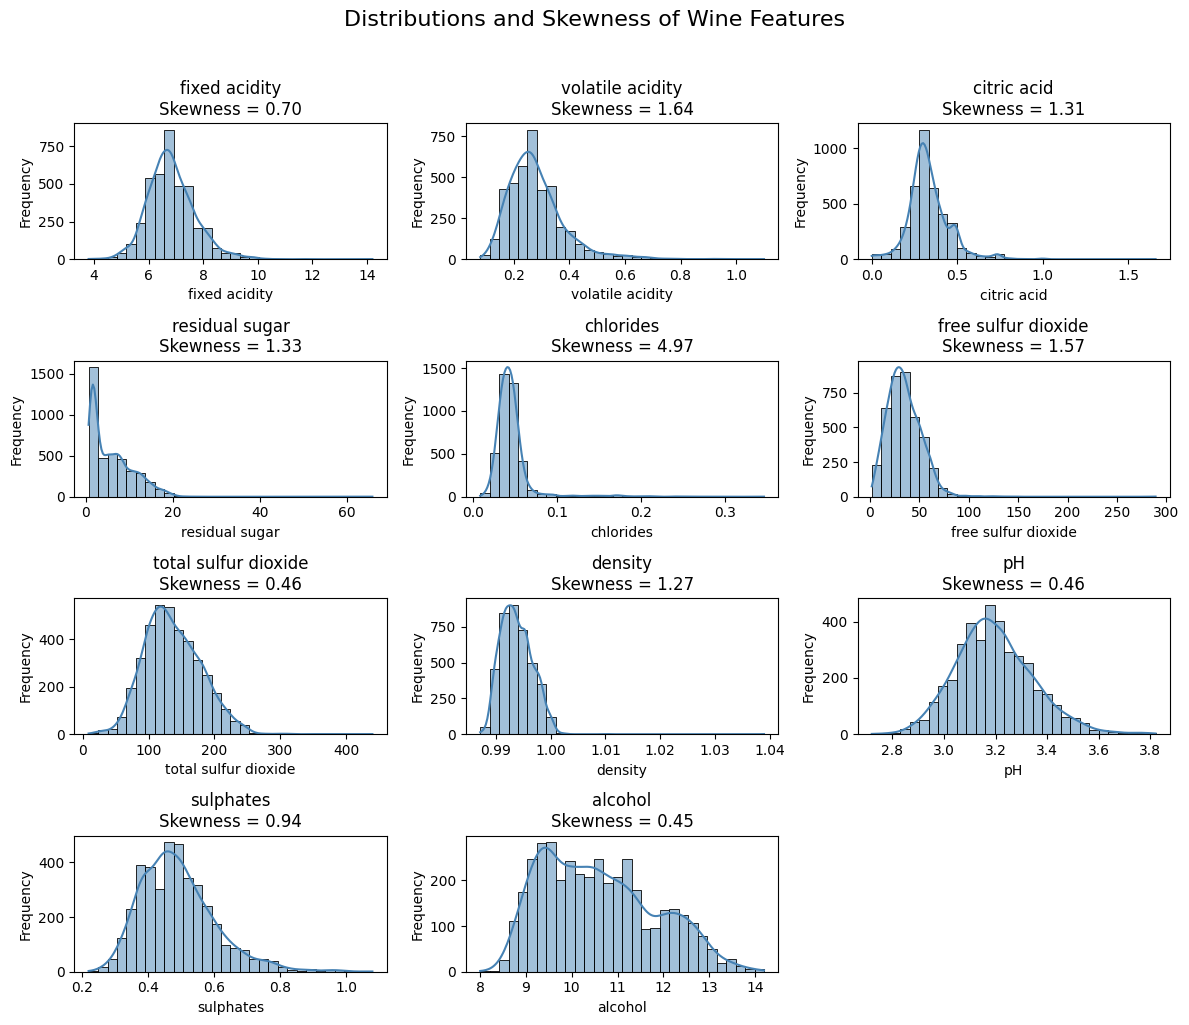

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only the 11 predictor variables
feature_columns = wine_df.drop(
    columns=["quality", "quality_class"]
).columns

# Create a 4-row by 3-column subplot grid
fig, axes = plt.subplots(
    nrows=4,
    ncols=3,
    figsize=(12, 10)
)

# Convert the 2-dimensional axes grid into a 1-dimensional array
axes = axes.flatten()

# Create one histogram with a KDE curve for each predictor
for index, column in enumerate(feature_columns):

    sns.histplot(
        data=wine_df,
        x=column,
        kde=True,
        bins=30,
        color="steelblue",
        ax=axes[index]
    )

    # Calculate the skewness of the current feature
    skew_value = wine_df[column].skew()

    axes[index].set_title(
        f"{column}\nSkewness = {skew_value:.2f}"
    )
    axes[index].set_xlabel(column)
    axes[index].set_ylabel("Frequency")

# Delete the unused twelfth subplot
for index in range(len(feature_columns), len(axes)):
    fig.delaxes(axes[index])

plt.suptitle(
    "Distributions and Skewness of Wine Features",
    fontsize=16,
    y=1.02
)

plt.tight_layout()
plt.show()

In [15]:
skewness_summary = (
    wine_df[feature_columns]
    .skew()
    .sort_values(ascending=False)
    .reset_index()
)

skewness_summary.columns = ["feature", "skewness"]

skewness_summary["absolute_skewness"] = (
    skewness_summary["skewness"].abs()
)

skewness_summary["interpretation"] = np.select(
    [
        skewness_summary["absolute_skewness"] < 0.5,
        skewness_summary["absolute_skewness"] < 1.0
    ],
    [
        "approximately symmetrical",
        "moderately skewed"
    ],
    default="strongly skewed"
)

skewness_summary

,feature,skewness,absolute_skewness,interpretation
0,chlorides,4.969076,4.969076,strongly skewed
1,volatile acidity,1.641081,1.641081,strongly skewed
2,free sulfur dioxide,1.566680,1.566680,strongly skewed
3,residual sugar,1.333639,1.333639,strongly skewed
4,citric acid,1.310601,1.310601,strongly skewed
5,density,1.273318,1.273318,strongly skewed
6,sulphates,0.937853,0.937853,moderately skewed
7,fixed acidity,0.696100,0.696100,moderately skewed
8,total sulfur dioxide,0.456800,0.456800,approximately symmetrical
9,pH,0.455457,0.455457,approximately symmetrical


### Interpretation of Feature Skewness

The skewness analysis shows that six predictor variables are strongly positively skewed:

- chlorides,
- volatile acidity,
- free sulfur dioxide,
- residual sugar,
- citric acid,
- and density.

Chlorides has the strongest skewness:

Skewness(chlorides) = 4.97


This indicates that most wines have relatively low chloride values, while a small number of wines have much higher values.

Two variables, sulphates and fixed acidity, are moderately positively skewed. Total sulfur dioxide, pH and alcohol are approximately symmetrical according to the selected threshold:

|Skewness| < 0.5


All calculated skewness values are positive. Therefore, the asymmetric distributions have longer right tails.

Strong skewness may influence K-Nearest Neighbors because extreme values can affect the calculated distances between observations. It may also influence standardization because the mean and standard deviation are sensitive to extreme values.

However, scaling and transformation are different operations:

- **Transformation** changes the shape of a distribution.
- **Scaling** changes the numerical range or scale.
- Standardization does not necessarily remove skewness.
- Min–max normalization does not remove skewness.

Standardization is calculated as:

z = (x − μtrain) / σtrain

where:

x = original feature value  
μ\_train = training-set mean  
σ\_train = training-set standard deviation  
z = standardized value

Min–max normalization is calculated as:

x′ = (x − xmin\_train) / (xmax\_train − xmin\_train)

Both scaling methods change the numerical scale but generally preserve the original distribution's skewness.

A power transformation, such as Yeo–Johnson, can be used to reduce skewness. Because it estimates transformation parameters from the data, it must be fitted only on the training set.

The project will therefore compare classification models using:

1. original unscaled features,
2. standardized features,
3. normalized features,
4. and transformed plus standardized features.

The train–test split will be performed before fitting any scaler or learned transformation. This prevents information from the test set from influencing preprocessing and avoids data leakage.


## 7. Defining the Features and Target

In supervised machine learning, the dataset is split into:

**X** = predictor variables/features  
**y** = target variable to be predicted

For this project:

**X** = physicochemical wine features, such as fixed acidity, volatile acidity, alcohol, and others

**y = quality\_class**

The original **quality** column is not included in **X** because **quality\_class** was created from it. Including it would cause **target leakage**, meaning the model would already have access to the answer.

The model relationship is:

**X → f(X) → ŷ**

where:

**X** = wine features  
**f** = classification model  
**ŷ** = predicted quality class

The feature matrix is:

**X ∈ R^(3961 × 11)**

This means there are **3,961 wine samples** and **11 predictor variables**.

The target vector is:

**y ∈ {0, 1}^3961**

where:

**y = 0** = lower-quality wine  
**y = 1** = acceptable or higher-quality wine


In [16]:
# X contains only the 11 physicochemical predictor variables
X = wine_df.drop(
    columns=["quality", "quality_class"]
)

# y contains the binary classification target
y = wine_df["quality_class"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

print("\nPredictor columns:")
print(X.columns.tolist())

print("\nTarget distribution:")
print(y.value_counts().sort_index())

Shape of X: (3961, 11)
Shape of y: (3961,)

Predictor columns:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target distribution:
quality_class
0    1348
1    2613
Name: count, dtype: int64




## 8. Stratified Train–Test Split

The dataset is divided into a training set and a test set:

**D = D\_train ∪ D\_test**

and:

**D\_train ∩ D\_test = ∅**

This means the training and test sets do not overlap.

An  **80/20 split** is used:

**80% = training data**  
**20% = test data**

The training set is used to fit preprocessing methods and train the model. The test set is kept unseen and used to evaluate model performance on new data.

Stratification is applied because the target classes are not perfectly balanced:

**P\_train(y = k) ≈ P\_test(y = k) ≈ P\_complete(y = k), where k ∈ {0, 1}**

This keeps the class proportions similar in the full dataset, training set, and test set.

**random\_state = 42** makes the split reproducible, so the same train-test split is produced each time.



P\_train(y = k) ≈ P\_test(y = k) ≈ P\_complete(y = k), where k ∈ {0, 1}

P = proportion  
P\_train = proportion in the training set  
P\_test = proportion in the test set  
P\_complete = proportion in the full dataset  
y = target variable  
k = class 0 or class 1  
y = k = observations in class k  
≈ = approximately equal



In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (3168, 11)
X_test shape: (793, 11)
y_train shape: (3168,)
y_test shape: (793,)


In [18]:
class_proportion_check = pd.DataFrame({
    "complete_dataset": y.value_counts(normalize=True).sort_index(),
    "training_set": y_train.value_counts(normalize=True).sort_index(),
    "test_set": y_test.value_counts(normalize=True).sort_index()
}).mul(100).round(2)

class_proportion_check.index = [
    "Lower quality (0)",
    "Acceptable/higher quality (1)"
]

class_proportion_check

,complete_dataset,training_set,test_set
Lower quality (0),34.03,34.03,34.05
Acceptable/higher quality (1),65.97,65.97,65.95



**Verification of Stratification**

The class proportions after the split are very similar:

Lower quality (0): complete = 34.03%, train = 34.03%, test = 34.05%  
Acceptable/higher quality (1): complete = 65.97%, train = 65.97%, test = 65.95%

This confirms that stratification worked because the class proportions are approximately equal in the complete dataset, training set, and test set:

**P\_train(y = k) ≈ P\_test(y = k) ≈ P\_complete(y = k)**

The small difference of about 0.02 percentage points occurs because observations cannot be split into fractions. Therefore, `stratify=y` helped keep both quality classes represented fairly in training and testing.


In [19]:
# Combine the training features and target using their matching indices
training_analysis_df = X_train.copy()
training_analysis_df["quality_class"] = y_train

# Calculate the correlation of every feature with the target
target_correlations = (
    training_analysis_df
    .corr(numeric_only=True)[["quality_class"]]
    .drop(index="quality_class")
    .sort_values(
        by="quality_class",
        ascending=False
    )
)

target_correlations

,quality_class
alcohol,0.408307
pH,0.103115
sulphates,0.060480
citric acid,0.020544
free sulfur dioxide,0.007579
fixed acidity,-0.101552
residual sugar,-0.109196
total sulfur dioxide,-0.164865
chlorides,-0.186942
volatile acidity,-0.212550


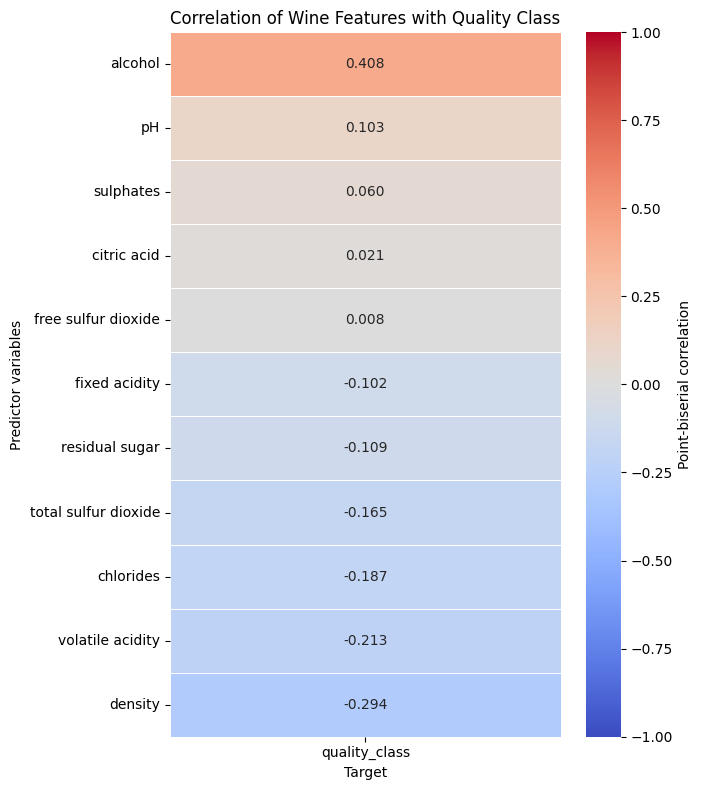

In [20]:
plt.figure(figsize=(7, 8))

sns.heatmap(
    target_correlations,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={
        "label": "Point-biserial correlation"
    }
)

plt.title(
    "Correlation of Wine Features with Quality Class"
)
plt.xlabel("Target")
plt.ylabel("Predictor variables")

plt.tight_layout()
plt.show()

## Feature–Target Correlations

Most features have weak individual correlations with "quality_class", meaning no single physicochemical variable can clearly separate lower-quality wines from acceptable or higher-quality wines.

However, weak correlation does not mean a feature is useless. Correlation checks one feature at a time, while machine-learning models use all features together:

**ŷ = f(x1, x2, ..., x11)**


Because wine quality also depends partly on sensory judgement, similar wines may receive different scores. Therefore, perfect prediction is unrealistic.

For this reason, features are not removed only because they have weak correlations. Their usefulness is evaluated through trained classification models.


## 10. Majority-Class Baseline Model

Before training the real models, a `DummyClassifier` is used as a baseline. It provides a minimum performance reference.

The baseline does not use wine features such as alcohol, acidity, or sugar. It simply predicts the most common class in the training set for every wine.

Since class **1** is the majority class:

**ŷᵢ = 1 for every wine i**

Accuracy is calculated as:

**Accuracy = correct predictions / total predictions**

Because about **65.95%** of test wines are class **1**, the baseline accuracy is:

**Baseline test accuracy ≈ 65.95%**

This does not mean the model has learned useful patterns. It only performs well because class **1** is more common.

Therefore, trained models should:

* perform better than **65.95%**
* reach the project goal of at least **70% test accuracy**
* predict both class **0** and class **1**
* be evaluated using precision, recall, and the confusion matrix

The "DummyClassifier" is used only as a comparison benchmark, not as the final model.


In [21]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score

# Create a baseline that always predicts the majority training class
baseline_model = DummyClassifier(
    strategy="most_frequent"
)

# Fit the baseline using only the training data
baseline_model.fit(X_train, y_train)

# Generate predictions for training and test data
baseline_train_predictions = baseline_model.predict(X_train)
baseline_test_predictions = baseline_model.predict(X_test)

# Calculate training and test accuracy
baseline_train_accuracy = accuracy_score(
    y_train,
    baseline_train_predictions
)

baseline_test_accuracy = accuracy_score(
    y_test,
    baseline_test_predictions
)

print(
    f"Baseline training accuracy: "
    f"{baseline_train_accuracy:.2%}"
)

print(
    f"Baseline test accuracy: "
    f"{baseline_test_accuracy:.2%}"
)

print(
    "Unique test predictions:",
    np.unique(baseline_test_predictions)
)

Baseline training accuracy: 65.97%
Baseline test accuracy: 65.95%
Unique test predictions: [1]




 ## 11. KNN Classification Model Before Scaling**

The first machine-learning model is a **K-Nearest Neighbors (KNN)** classifier trained using the original, unscaled features.

The baseline model always predicted class **1** and achieved:

**Baseline test accuracy = 65.95%**

Unlike the baseline, KNN uses the **11 physicochemical features** to classify each wine.

For this model:

**k = 10**

This means KNN looks at the **10 nearest training wines** and predicts the most common class among them.

Distance is measured using Euclidean distance:

**d(x, z) = √Σ(xj − zj)²**

where:

**x and z** = two wines  
**p** = number of predictor variables  
**xj and zj** = values of feature j

The model is trained using:

**(X\_train, y\_train)**

and predicts the test classes using:

**X\_test → ŷ\_test**

This first model uses unscaled features. Its performance will later be compared with KNN after normalization and standardization.


In [22]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the unscaled KNN classifier
knn_unscaled = KNeighborsClassifier(
    n_neighbors=10
)

# Train only on the original training data
knn_unscaled.fit(
    X_train,
    y_train
)

# Make predictions on training and test data
y_train_pred_unscaled = knn_unscaled.predict(
    X_train
)

y_test_pred_unscaled = knn_unscaled.predict(
    X_test
)

# Calculate accuracy
train_accuracy_unscaled = accuracy_score(
    y_train,
    y_train_pred_unscaled
)

test_accuracy_unscaled = accuracy_score(
    y_test,
    y_test_pred_unscaled
)

# Calculate the generalization gap
generalization_gap_unscaled = (
    train_accuracy_unscaled
    - test_accuracy_unscaled
)

# Compare test accuracy with the baseline
improvement_over_baseline = (
    test_accuracy_unscaled
    - baseline_test_accuracy
)

print(
    f"Unscaled KNN training accuracy: "
    f"{train_accuracy_unscaled:.2%}"
)

print(
    f"Unscaled KNN test accuracy: "
    f"{test_accuracy_unscaled:.2%}"
)

print(
    f"Generalization gap: "
    f"{generalization_gap_unscaled:.2%}"
)

print(
    f"Improvement over baseline: "
    f"{improvement_over_baseline:.2%}"
)

Unscaled KNN training accuracy: 74.40%
Unscaled KNN test accuracy: 67.84%
Generalization gap: 6.56%
Improvement over baseline: 1.89%


 ### Interpretation of KNN Before Scaling

The unscaled KNN model achieved:

Training accuracy = 74.40%  
Test accuracy = 67.84%

It improved over the baseline by:

67.84% − 65.95% = 1.89 percentage points

This shows that the model learned some useful information from the features, but the improvement was small.

The generalization gap was:

74.40% − 67.84% = 6.56%

This means the model performed better on training data than on test data, suggesting some overfitting.


This indicates that the classifier performed better on the training data than on unseen test data. The difference suggests some overfitting.

The test accuracy also remained below the project objective:

\[
67.84\%<70\%
\]

Because KNN calculates distances and the predictor variables have different numerical scales, the unscaled result may be influenced disproportionately by variables with larger ranges, such as total sulfur dioxide.

The next step is to apply min–max normalization and retrain the same KNN model using the same value of \(k\). This provides a fair comparison in which only the feature scaling method changes.



 ### Confusion Matrix for KNN Before Scaling

A confusion matrix compares actual classes with predicted classes.

For binary classification:

**\[\[TN, FP], \[FN, TP]]**

where:

TN = class 0 correctly predicted as 0  
FP = class 0 incorrectly predicted as 1  
FN = class 1 incorrectly predicted as 0  
TP = class 1 correctly predicted as 1

Accuracy shows the overall correct predictions, while the confusion matrix shows how well the model predicts each class.


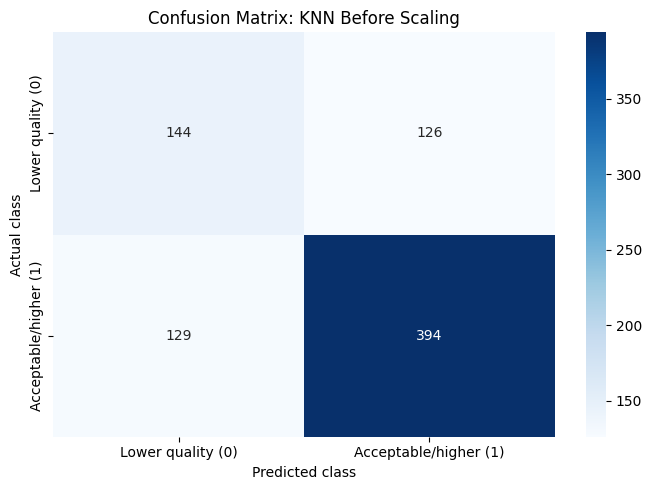

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
knn_unscaled_confusion = confusion_matrix(
    y_test,
    y_test_pred_unscaled
)

# Display it as a coloured heatmap
plt.figure(figsize=(7, 5))

sns.heatmap(
    knn_unscaled_confusion,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    yticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ]
)

plt.title("Confusion Matrix: KNN Before Scaling")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.tight_layout()
plt.show()

In [24]:
from sklearn.preprocessing import MinMaxScaler

# Create the min–max normalizer
minmax_scaler = MinMaxScaler()

# Learn training minima and maxima and normalize X_train
X_train_normalized = minmax_scaler.fit_transform(
    X_train
)

# Normalize X_test using the training parameters
X_test_normalized = minmax_scaler.transform(
    X_test
)

# Convert the results back into DataFrames
X_train_normalized = pd.DataFrame(
    X_train_normalized,
    columns=X_train.columns,
    index=X_train.index
)

X_test_normalized = pd.DataFrame(
    X_test_normalized,
    columns=X_test.columns,
    index=X_test.index
)

print("Normalized training shape:", X_train_normalized.shape)
print("Normalized test shape:", X_test_normalized.shape)

X_train_normalized.head()

Normalized training shape: (3168, 11)
Normalized test shape: (793, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
3384,0.317308,0.356436,0.144578,0.032209,0.091988,0.076655,0.179070,0.029111,0.200000,0.186047,0.870968
3278,0.230769,0.148515,0.168675,0.177914,0.118694,0.181185,0.286047,0.155967,0.427273,0.174419,0.435484
2166,0.269231,0.257426,0.210843,0.082822,0.160237,0.101045,0.325581,0.159244,0.345455,0.290698,0.225806
3725,0.250000,0.287129,0.114458,0.059816,0.086053,0.118467,0.253488,0.084827,0.318182,0.232558,0.516129
1605,0.269231,0.158416,0.216867,0.115031,0.106825,0.181185,0.395349,0.167534,0.327273,0.232558,0.193548


In [25]:
from sklearn.preprocessing import MinMaxScaler

normalizer = MinMaxScaler()
normalizer

MinMaxScaler()

In [26]:
normalization_check = pd.DataFrame({
    "training_minimum": X_train_normalized.min(),
    "training_maximum": X_train_normalized.max()
}).round(3)

normalization_check

,training_minimum,training_maximum
fixed acidity,0.0,1.0
volatile acidity,0.0,1.0
citric acid,0.0,1.0
residual sugar,0.0,1.0
chlorides,0.0,1.0
free sulfur dioxide,0.0,1.0
total sulfur dioxide,0.0,1.0
density,0.0,1.0
pH,0.0,1.0
sulphates,0.0,1.0


### Verification of Min–Max Normalization

The normalization check confirms that every training feature has: \[
x'_{\min}=0
\]

and:

\[
x'_{\max}=1
\]

Therefore:

0 ≤ x′ ≤ 1


for all observations in the normalized training set.

This confirms that "MinMaxScaler" successfully placed all 11 predictor variables on the same numerical scale. Consequently, features with originally large values, such as total sulfur dioxide, can no longer dominate the KNN distance calculation merely because of their measurement range.

The test set was transformed using the minimum and maximum values learned from the training set. Test-set values are not guaranteed to remain strictly between 0 and 1 if a test observation falls outside the training range. This is acceptable because the test set was not used to fit the normalizer.

In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Create the normalized KNN model
knn_normalized = KNeighborsClassifier(
    n_neighbors=5
)

# Train only on the normalized training data
knn_normalized.fit(
    X_train_normalized,
    y_train
)

# Make predictions
y_train_pred_normalized = knn_normalized.predict(
    X_train_normalized
)

y_test_pred_normalized = knn_normalized.predict(
    X_test_normalized
)

# Calculate accuracy
train_accuracy_normalized = accuracy_score(
    y_train,
    y_train_pred_normalized
)

test_accuracy_normalized = accuracy_score(
    y_test,
    y_test_pred_normalized
)

# Calculate comparison measures
generalization_gap_normalized = (
    train_accuracy_normalized
    - test_accuracy_normalized
)

improvement_over_baseline_normalized = (
    test_accuracy_normalized
    - baseline_test_accuracy
)

change_from_unscaled = (
    test_accuracy_normalized
    - test_accuracy_unscaled
)

print(
    f"Normalized KNN training accuracy: "
    f"{train_accuracy_normalized:.2%}"
)

print(
    f"Normalized KNN test accuracy: "
    f"{test_accuracy_normalized:.2%}"
)

print(
    f"Generalization gap: "
    f"{generalization_gap_normalized:.2%}"
)

print(
    f"Improvement over baseline: "
    f"{improvement_over_baseline_normalized:.2%}"
)

print(
    f"Change from unscaled KNN: "
    f"{change_from_unscaled:.2%}"
)

Normalized KNN training accuracy: 82.80%
Normalized KNN test accuracy: 73.27%
Generalization gap: 9.53%
Improvement over baseline: 7.31%
Change from unscaled KNN: 5.42%


### Interpretation of KNN After Normalization

The KNN classifier trained with min–max normalized features achieved: Training accuracy = 82.80\%


Test accuracy = 73.27%

The model exceeded the project objective:73.27% > 70%


It also outperformed the majority-class baseline by approximately: 73.27% - 65.95% =7.32 percentage points. Compared with the unscaled KNN model, normalization increased test accuracy by: 73.27 % - 67.84 %= 5.43 percentage points.

This demonstrates that feature scaling materially improved KNN performance. Before normalization, predictors with large numerical ranges could dominate the Euclidean-distance calculation. After normalization, all predictors contributed on a comparable scale between 0 and 1.

However, the generalization gap was: 82.80 % - 73.27% = 9.53 percentage points

This indicates some overfitting because the model performs considerably better on the training data than on unseen test data. Therefore, although the model achieved the 70% objective, further evaluation and tuning are necessary.

Accuracy alone is also insufficient. The confusion matrix, precision and recall must be examined to determine whether the model can identify both quality classes.

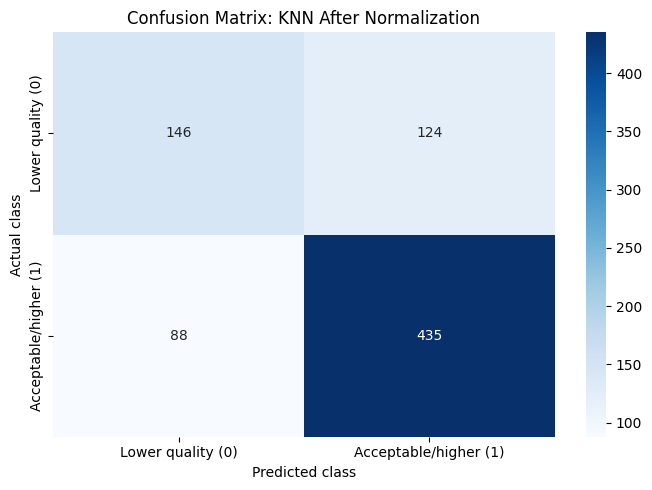

In [28]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

normalized_confusion_matrix = confusion_matrix(
    y_test,
    y_test_pred_normalized
)

plt.figure(figsize=(7, 5))

sns.heatmap(
    normalized_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ],
    yticklabels=[
        "Lower quality (0)",
        "Acceptable/higher (1)"
    ]
)

plt.title("Confusion Matrix: KNN After Normalization")
plt.xlabel("Predicted class")
plt.ylabel("Actual class")

plt.tight_layout()
plt.show()


### Interpretation of the Normalized KNN Confusion Matrix

The normalized KNN confusion matrix is: **\[\[146, 124], \[88, 435]]**

This means:

TN = 146 lower-quality wines correctly predicted as class 0  
FP = 124 lower-quality wines incorrectly predicted as class 1  
FN = 88 acceptable/higher-quality wines incorrectly predicted as class 0  
TP = 435 acceptable/higher-quality wines correctly predicted as class 1

Total test observations: 146 + 124 + 88 + 435 = 793

Correct predictions: 146 + 435 = 581

Test accuracy:

Accuracy = (TP + TN) / (TP + TN + FP + FN)  
Accuracy = (435 + 146) / 793 = 73.27%

Class 1 precision:

Precision = TP / (TP + FP)  
Precision = 435 / (435 + 124) ≈ 77.82%

Class 1 recall:

Recall = TP / (TP + FN)  
Recall = 435 / (435 + 88) ≈ 83.17%

Class 0 recall:

146 / (146 + 124) ≈ 54.07%

The model performs better at identifying acceptable/higher-quality wines than lower-quality wines. It achieved the 70% accuracy goal, but the 124 false positives show that more improvement is needed for detecting lower-quality wines.



 ### Classification Report for KNN After Normalization

The classification report evaluates the model for each class using precision, recall, and support.

Precision shows how reliable the model’s positive predictions are: **Precision = TP / (TP + FP)**

Recall shows how many actual observations of a class the model correctly identifies: **Recall = TP / (TP + FN)**

Support is the number of actual observations in each class.

Because the dataset is imbalanced, class-level results are important. Accuracy alone may hide weak performance on the minority class.


In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_test_pred_normalized,
        target_names=[
            "Lower quality (0)",
            "Acceptable/higher quality (1)"
        ]
    )
)

                               precision    recall  f1-score   support

            Lower quality (0)       0.62      0.54      0.58       270
Acceptable/higher quality (1)       0.78      0.83      0.80       523

                     accuracy                           0.73       793
                    macro avg       0.70      0.69      0.69       793
                 weighted avg       0.73      0.73      0.73       793




### Interpretation of the Normalized KNN Classification Report

The normalized KNN model achieved: **Accuracy = 73%**

This is higher than the baseline accuracy of **65.95%** and meets the project goal of **70%**.

For class 0, lower-quality wines:
Precision₀ = 62%  
Recall₀ = 54%

This means the model correctly identifies only about **54%** of actual lower-quality wines, so many lower-quality wines are still classified as acceptable/higher quality.

For class 1, acceptable/higher-quality wines:

Precision₁ = 78%  
Recall₁ = 83%

This means the model performs better at identifying acceptable/higher-quality wines.

Support values:

n₀ = 270  
n₁ = 523

Because class 1 has more observations, the weighted averages are influenced more by class 1. The macro averages treat both classes equally:

Macro precision = 70%  
Macro recall = 69%

Overall, the normalized KNN model is a useful preliminary model because it reaches the accuracy target, but it still needs improvement in detecting lower-quality wines.
